In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# === paths (поменяй под свой мак) ===
PARQUET_PATH = Path("/Users/zhasik/Desktop/krisha/data/index/index.parquet")
PROJECT_ROOT = Path("/Users/zhasik/Desktop/krisha")


In [2]:
df = pd.read_parquet(PARQUET_PATH)
print("shape:", df.shape)
df.head(3)


shape: (1879, 17)


,ad_id,url,price,area,price_per_m2,log_price_per_m2,rooms,district,building_type,residential_complex,year_built,floor,floors_total,latitude,longitude,image_paths,image_urls
0,1008270130,https://krisha.kz/a/show/1008270130,33000000,40.0,8.250000e+05,13.623139,2,Медеуский р-н,монолитный,Mereke,2024,5,6,43.292679,77.013974,"[data/images/1008270130/01.jpg, data/images/10...",[https://krisha-photos.kcdn.online/webp/20/208...
1,1002526087,https://krisha.kz/a/show/1002526087,56500000,75.1,7.523302e+05,13.530931,3,Алмалинский р-н,монолитный,Auezov City,2023,14,15,43.261495,76.899913,"[data/images/1002526087/01.jpg, data/images/10...",[https://krisha-photos.kcdn.online/webp/f6/f6b...
2,1005774259,https://krisha.kz/a/show/1005774259,130000000,95.0,1.368421e+06,14.129168,3,Алмалинский р-н,монолитный,O'NER Towers,2024,17,17,43.238930,76.883781,"[data/images/1005774259/01.jpg, data/images/10...",[https://krisha-photos.kcdn.online/webp/3e/3e7...


In [3]:
import json

def ensure_list(x):
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, np.ndarray):
        return x.tolist()
    if x is None:
        return []
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        if s.startswith("[") and s.endswith("]"):
            try:
                return json.loads(s)
            except Exception:
                pass
        return [p.strip().strip('"').strip("'") for p in s.split(",") if p.strip()]
    return []

df["image_paths_list"] = df["image_paths"].apply(ensure_list)
df["n_images"] = df["image_paths_list"].apply(len)

df[["ad_id","n_images"]].head()


,ad_id,n_images
0,1008270130,6
1,1002526087,8
2,1005774259,8
3,1000941933,8
4,1007016940,8


In [4]:
CURRENT_YEAR = 2026

df_feat = df.copy()

# optional geo + RC fields
if "residential_complex" not in df_feat.columns:
    df_feat["residential_complex"] = "unknown"
df_feat["residential_complex"] = df_feat["residential_complex"].fillna("unknown").astype(str)
df_feat["residential_complex"] = df_feat["residential_complex"].replace({"": "unknown", "None": "unknown", "nan": "unknown"})

for c in ["latitude", "longitude"]:
    if c not in df_feat.columns:
        df_feat[c] = np.nan
    df_feat[c] = pd.to_numeric(df_feat[c], errors="coerce")

df_feat["has_geo"] = (df_feat["latitude"].notna() & df_feat["longitude"].notna()).astype(int)
df_feat["has_residential_complex"] = (df_feat["residential_complex"] != "unknown").astype(int)

if df_feat["latitude"].notna().any():
    df_feat["latitude"] = df_feat["latitude"].fillna(df_feat["latitude"].median())
else:
    df_feat["latitude"] = 43.238949

if df_feat["longitude"].notna().any():
    df_feat["longitude"] = df_feat["longitude"].fillna(df_feat["longitude"].median())
else:
    df_feat["longitude"] = 76.889709

# derived
df_feat["floor_ratio"] = df_feat["floor"] / df_feat["floors_total"]
df_feat["is_first"] = (df_feat["floor"] == 1).astype(int)
df_feat["is_last"]  = (df_feat["floor"] == df_feat["floors_total"]).astype(int)
df_feat["building_age"] = CURRENT_YEAR - df_feat["year_built"]

# safety clips
df_feat["floor_ratio"] = df_feat["floor_ratio"].clip(0, 1)

TARGET = "log_price_per_m2"

FEATURES_NUM = [
    "area", "rooms", "floor", "floors_total", "floor_ratio", "is_first", "is_last", "building_age",
    "latitude", "longitude", "has_geo", "has_residential_complex"
]

FEATURES_CAT = ["district", "building_type", "residential_complex"]

FEATURES = FEATURES_NUM + FEATURES_CAT

df_feat[FEATURES + [TARGET]].isna().mean().sort_values(ascending=False).head(20)


area                       0.0
rooms                      0.0
floor                      0.0
floors_total               0.0
floor_ratio                0.0
is_first                   0.0
is_last                    0.0
building_age               0.0
latitude                   0.0
longitude                  0.0
has_geo                    0.0
has_residential_complex    0.0
district                   0.0
building_type              0.0
residential_complex        0.0
log_price_per_m2           0.0
dtype: float64

In [5]:
from sklearn.model_selection import train_test_split

X = df_feat[FEATURES]
y = df_feat[TARGET]

def pick_stratify(series):
    vc = series.value_counts(dropna=False)
    # Stratified split requires >=2 samples in every class
    if len(vc) == 0 or vc.min() < 2:
        return None
    return series

strat_all = pick_stratify(df_feat["district"])
if strat_all is None:
    print("[warn] stratify отключен на первом split: есть классы district с <2 объектов")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=strat_all,
)

strat_temp = pick_stratify(X_temp["district"])
if strat_temp is None:
    print("[warn] stratify отключен на втором split: в X_temp есть классы district с <2 объектов")

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=strat_temp,
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (1315, 15) Val: (282, 15) Test: (282, 15)


In [6]:
from catboost import CatBoostRegressor

cat_features_idx = [X.columns.get_loc(c) for c in FEATURES_CAT]

model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    early_stopping_rounds=200,
    verbose=200
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    cat_features=cat_features_idx
)


0:	learn: 0.2937511	test: 0.3203093	best: 0.3203093 (0)	total: 67.1ms	remaining: 3m 21s
200:	learn: 0.1411128	test: 0.1835034	best: 0.1835034 (200)	total: 470ms	remaining: 6.55s
400:	learn: 0.1080061	test: 0.1708822	best: 0.1708822 (400)	total: 958ms	remaining: 6.21s
600:	learn: 0.0898716	test: 0.1675811	best: 0.1675185 (598)	total: 1.43s	remaining: 5.72s
800:	learn: 0.0779873	test: 0.1670357	best: 0.1669674 (760)	total: 1.83s	remaining: 5.04s
1000:	learn: 0.0683958	test: 0.1668529	best: 0.1668093 (949)	total: 2.24s	remaining: 4.47s
1200:	learn: 0.0612032	test: 0.1668259	best: 0.1666841 (1189)	total: 2.65s	remaining: 3.96s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.1666841135
bestIteration = 1189

Shrink model to first 1190 iterations.


In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

def eval_block(model, X, y, name):
    pred_log = model.predict(X)

    r2 = r2_score(y, pred_log)

    ppm2_true = np.exp(y)
    ppm2_pred = np.exp(pred_log)
    mae_ppm2 = mean_absolute_error(ppm2_true, ppm2_pred)

    print(f"\n{name}")
    print(f"R2 (log_price_per_m2): {r2:.4f}")
    print(f"MAE (price_per_m2): {mae_ppm2:,.0f} ₸/м²")
    return r2, mae_ppm2

r2_tr, mae_tr = eval_block(model, X_train, y_train, "Train")
r2_va, mae_va = eval_block(model, X_val, y_val, "Val")
r2_te, mae_te = eval_block(model, X_test, y_test, "Test")



Train
R2 (log_price_per_m2): 0.9268
MAE (price_per_m2): 52,128 ₸/м²

Val
R2 (log_price_per_m2): 0.7355
MAE (price_per_m2): 109,144 ₸/м²

Test
R2 (log_price_per_m2): 0.7221
MAE (price_per_m2): 94,430 ₸/м²


In [8]:
def price_mae(model, X, y, name):
    pred_log = model.predict(X)
    ppm2_pred = np.exp(pred_log)
    ppm2_true = np.exp(y)

    price_pred = ppm2_pred * X["area"].astype(float).values
    price_true = ppm2_true * X["area"].astype(float).values

    mae_price = mean_absolute_error(price_true, price_pred)
    print(f"{name} MAE(price): {mae_price:,.0f} ₸")
    return mae_price

mae_price_test = price_mae(model, X_test, y_test, "Test")


Test MAE(price): 7,811,243 ₸


,feature,importance
9,longitude,17.262908
8,latitude,15.633074
12,district,14.888016
7,building_age,12.852926
0,area,11.211511
3,floors_total,6.905282
14,residential_complex,6.347611
4,floor_ratio,4.295716
13,building_type,4.259608
2,floor,2.443865


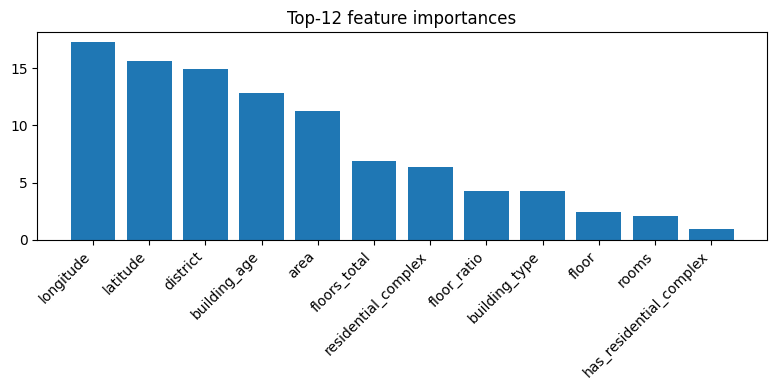

In [9]:
fi = pd.DataFrame({
    "feature": FEATURES,
    "importance": model.get_feature_importance()
}).sort_values("importance", ascending=False)

display(fi)

plt.figure(figsize=(8,4))
plt.bar(fi["feature"][:12], fi["importance"][:12])
plt.xticks(rotation=45, ha="right")
plt.title("Top-12 feature importances")
plt.tight_layout()
plt.show()


In [10]:
from pathlib import Path

OUT_DIR = PROJECT_ROOT / "models"
OUT_DIR.mkdir(parents=True, exist_ok=True)

model_path = OUT_DIR / "catboost_tabular_baseline.cbm"
model.save_model(str(model_path))
print("Saved:", model_path)

# сохраним ad_id для test set (чтобы потом делать сравнения 1-в-1)
splits_dir = PROJECT_ROOT / "data" / "processed"
splits_dir.mkdir(parents=True, exist_ok=True)

pd.Series(df_feat.loc[X_train.index, "ad_id"].astype(str).values).to_csv(splits_dir / "train_ad_ids.csv", index=False)
pd.Series(df_feat.loc[X_val.index, "ad_id"].astype(str).values).to_csv(splits_dir / "val_ad_ids.csv", index=False)
pd.Series(df_feat.loc[X_test.index, "ad_id"].astype(str).values).to_csv(splits_dir / "test_ad_ids.csv", index=False)

print("Saved splits to:", splits_dir)


Saved: /Users/zhasik/Desktop/krisha/models/catboost_tabular_baseline.cbm
Saved splits to: /Users/zhasik/Desktop/krisha/data/processed


In [11]:
from pathlib import Path

PROJECT_ROOT = Path("/Users/zhasik/Desktop/krisha")

print((PROJECT_ROOT / "models" / "catboost_tabular_baseline.cbm").exists())
print((PROJECT_ROOT / "data" / "processed" / "train_ad_ids.csv").exists())
print((PROJECT_ROOT / "data" / "processed" / "val_ad_ids.csv").exists())
print((PROJECT_ROOT / "data" / "processed" / "test_ad_ids.csv").exists())


True
True
True
True


In [12]:
import json
from pathlib import Path

PROJECT_ROOT = Path("/Users/zhasik/Desktop/krisha")
OUT = PROJECT_ROOT / "models"
OUT.mkdir(parents=True, exist_ok=True)

CURRENT_YEAR = 2026
TARGET = "log_price_per_m2"
FEATURES_NUM = [
    "area","rooms","floor","floors_total","floor_ratio","is_first","is_last","building_age",
    "latitude","longitude","has_geo","has_residential_complex"
]
FEATURES_CAT = ["district","building_type","residential_complex"]
FEATURES = FEATURES_NUM + FEATURES_CAT

v1_meta = {
    "version": "v1_tabular_baseline",
    "target": TARGET,
    "current_year": CURRENT_YEAR,
    "features_num": FEATURES_NUM,
    "features_cat": FEATURES_CAT,
    "features": FEATURES,
    "split_seed": 42,
    "metrics_test": {
        "r2_log": 0.5928,
        "mae_ppm2": 114077,
        "mae_price": 10176110
    }
}

meta_path = OUT / "v1_metadata.json"
meta_path.write_text(json.dumps(v1_meta, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", meta_path)


Saved: /Users/zhasik/Desktop/krisha/models/v1_metadata.json


In [13]:
import numpy as np
import pandas as pd
import json
from pathlib import Path
from catboost import CatBoostRegressor

PROJECT_ROOT = Path("/Users/zhasik/Desktop/krisha")

model_path = PROJECT_ROOT / "models" / "catboost_tabular_baseline.cbm"
meta = json.loads((PROJECT_ROOT / "models" / "v1_metadata.json").read_text(encoding="utf-8"))

model = CatBoostRegressor()
model.load_model(str(model_path))

def make_features_one(x: dict) -> pd.DataFrame:
    area = float(x["area"])
    rooms = int(x["rooms"])
    floor = int(x["floor"])
    floors_total = int(x["floors_total"])
    year_built = int(x["year_built"])
    district = str(x["district"])
    building_type = str(x["building_type"])

    residential_complex = str(x.get("residential_complex") or "unknown")

    lat = x.get("latitude", None)
    lon = x.get("longitude", None)
    try:
        lat = float(lat) if lat is not None else np.nan
    except Exception:
        lat = np.nan
    try:
        lon = float(lon) if lon is not None else np.nan
    except Exception:
        lon = np.nan

    has_geo = int(np.isfinite(lat) and np.isfinite(lon))
    has_residential_complex = int(residential_complex not in ["", "unknown", "None", "nan"])

    if not np.isfinite(lat):
        lat = 43.238949
    if not np.isfinite(lon):
        lon = 76.889709

    floor_ratio = min(max(floor / floors_total, 0.0), 1.0)
    is_first = int(floor == 1)
    is_last = int(floor == floors_total)
    building_age = meta["current_year"] - year_built

    row = {
        "area": area,
        "rooms": rooms,
        "floor": floor,
        "floors_total": floors_total,
        "floor_ratio": floor_ratio,
        "is_first": is_first,
        "is_last": is_last,
        "building_age": building_age,
        "latitude": lat,
        "longitude": lon,
        "has_geo": has_geo,
        "has_residential_complex": has_residential_complex,
        "district": district,
        "building_type": building_type,
        "residential_complex": residential_complex,
    }
    return pd.DataFrame([row], columns=meta["features"])

def predict_price(x: dict):
    X1 = make_features_one(x)
    pred_log = float(model.predict(X1))
    ppm2 = float(np.exp(pred_log))
    price = ppm2 * float(x["area"])
    return {"price": price, "price_per_m2": ppm2, "pred_log_ppm2": pred_log}

# пример вызова
predict_price({
    "area": 75.1,
    "rooms": 3,
    "floor": 14,
    "floors_total": 15,
    "year_built": 2023,
    "district": "Алмалинский р-н",
    "building_type": "монолитный",
    "residential_complex": "RAMS City",
    "latitude": 43.2368,
    "longitude": 76.9093,
})


/var/folders/ns/k49cn2y90z511xzg2m9mxjf40000gn/T/ipykernel_37203/1809862142.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pred_log = float(model.predict(X1))


{'price': 67607483.45573978,
 'price_per_m2': 900232.8023400771,
 'pred_log_ppm2': 13.710408678124073}